# Unsupervised RiePCA of EEG covariance matrices
## Neurophysiological exploration across heat times

For one subject, this notebook converts every left- or right-hand or foot or tongue motor-imagery trial into an OAS-regularized spatial covariance matrix

$$
\mathsf D=\{C_1,\ldots,C_n\}\subset\operatorname{SPD}(22).
$$

The analysis compares three reference strategies. Diffusion--Fréchet reference
points can change with $t$, a frozen fixed Diffusion--Fréchet reference
points for a selected $t$ and reuses them at every $t$, and a fixed full-dataset AIRM $k$-medoids set is reused at every $t$.


## 1. Install the dependencies

Run this cell once in a fresh Colab runtime. If Colab requests a restart,
restart the runtime and continue with Section 2.


In [1]:
!pip install -q "numpy<2.4" "scipy<1.18" "geomstats>=2.8,<3" "pyriemann>=0.8,<1" "moabb>=1.4,<2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 70.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.6/153.6 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 979.8/979.8 kB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.2/120.2 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 257.2/257.2 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 69.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.8/189.8 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.

In [2]:
import numpy, scipy
print(numpy.__version__, scipy.__version__)

2.1.3 1.16.3


## 2. Imports and the existing RiePCA helper

Keep the supplied RiePCA package in the same folder as this notebook. In
Colab, the cell asks you to upload it if `riepca_manifold.py` is not already
present. A supplied filename such as `riepca_manifold(2).py` is recognized and
renamed to the importable module name. The two imported objects have exactly
the same names as in the original notebook.


In [3]:
from pathlib import Path
import importlib.metadata as metadata_of_package
import shutil
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import kruskal, rankdata

from geomstats.geometry.spd_matrices import SPDAffineMetric, SPDMatrices
from moabb.datasets import BNCI2014_001
#from moabb.paradigms import LeftRightImagery
from moabb.paradigms import MotorImagery
from pyriemann.estimation import Covariances


helper_path = Path("riepca_manifold.py")
if not helper_path.exists():
    candidates = sorted(Path(".").glob("riepca_manifold*.py"))
    if not candidates:
        try:
            from google.colab import files
        except ImportError as error:
            raise FileNotFoundError(
                "Put the supplied riepca_manifold Python file beside this notebook."
            ) from error

        print("Please upload the supplied riepca_manifold Python file")
        uploaded = files.upload()
        candidates = [
            Path(name)
            for name in uploaded
            if "riepca_manifold" in name and name.endswith(".py")
        ]
    if not candidates:
        raise FileNotFoundError("No riepca_manifold Python file was found.")
    shutil.copyfile(candidates[0], helper_path)

from riepca_manifold import (
    check_riepca,
    field_inner_product_gram,
    riepca_manifold,
)


pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

packages = ["numpy", "scipy", "geomstats", "pyriemann", "moabb"]
print({name: metadata_of_package.version(name) for name in packages})


{'numpy': '2.1.3', 'scipy': '1.16.3', 'geomstats': '2.8.0', 'pyriemann': '0.12', 'moabb': '1.7.1'}


## 3. Experimental choices

The default analysis uses all selected trials from both sessions of subject 1 and treats them as equally weighted observations. `MotorImagery` retains the two tasks specified by `MOTOR_IMAGERY_TASKS`, with `n_classes=2`, and **applies a 13–30 Hz band-pass filter**. With the default choice of left- and right-hand motor imagery, this produces $n=144*2=288$ trials for subject 1.

**Data source.** The EEG recordings come from the [BNCI 2014-001 dataset](https://bnci-horizon-2020.eu/database/data-sets), originally released as **BCI Competition IV Dataset 2a**. The complete dataset contains recordings from nine subjects performing four motor-imagery tasks: left hand, right hand, both feet, and tongue. Each subject participated in two recording sessions on different days. The data are downloaded and processed through MOABB’s [`BNCI2014_001`](https://moabb.neurotechx.com/docs/generated/moabb.datasets.BNCI2014_001.html) interface. The present analysis uses subject 1 and retains only the two tasks specified by `MOTOR_IMAGERY_TASKS`, which are left- and right-hand motor imagery by default.


The default `raw` covariance representation retains differences in overall trial power. Change `COVARIANCE_VARIANT` to `"trace"` to remove global power by replacing $C_i$ with

$$
\frac{C_i}{\operatorname{tr}(C_i)}.
$$

The dimension of $\operatorname{SPD}(22)$ is

$$
\frac{22(22+1)}{2}=253.
$$


**Reference strategies.** Three strategies are compared. `diffusion_Fréchet` reselects the references at every heat time, as before. `diffusion_Fréchet_frozen` performs the same selection once at `FROZEN_MULTIPLIER` and reuses the resulting references at every heat time, so the field space no longer changes with $t$. `global_kmedoids` uses a fixed set of medoids selected from the full dataset.

**Heat times.** The field weight is

$$
\frac{\exp\left(-d^2/4t\right)}{2t}.
$$

It carries useful geometric information only while it varies appreciably across the data cloud. Once $4t$ dominates the largest squared distance, every exponential weight is approximately $1$, the field reduces to

$$
\frac{\operatorname{Log}_{R}(C)}{2t}.
$$


**Retained components.** With $n=288$ selected trials, the centered empirical field covariance operator has rank at most $n-1=287$. Thus, no more than $287$ components can carry nonzero sample variance, subject also to the dimension of the field space and the eigensolver's relative cutoff. The analysis does not retain all $287$ possible components: it sets`N_COMPONENTS_TO_KEEP = 40`, and retains at most the leading $40$ numerically supported components.


In [4]:
SUBJECT = 1
#SUBJECTS = list(range(1, 10))
COVARIANCE_VARIANT = "raw"       # "raw" or "trace"

# Diffusion--Fréchet epsilon-preimage construction.
EPSILON = 0.004
EPSILON_MODE = "absolute"        # "absolute" or "sublevel"
KNN_NEIGHBORS = 5
MAX_REFERENCES = 20               # use None to retain every component

# Fixed full-dataset AIRM k-medoids comparison.
K_MEDOIDS = 10
KMEDOIDS_MAX_ITER = 100

# Three reference strategies:
#   diffusion_Fréchet         references reselected at every t (t-dependent
#                             field space, so PC indices are not comparable
#                             across t);
#   diffusion_Fréchet_frozen  the same construction run once at
#                             FROZEN_MULTIPLIER and then reused at every t;
#   global_kmedoids           full-dataset AIRM medoids, also fixed.
# The two fixed strategies share one field space across all heat times, which
# is what makes the cross-t comparison in Section 10c meaningful.
REFERENCE_STRATEGIES = [
    "diffusion_Fréchet",
    "diffusion_Fréchet_frozen",
    "global_kmedoids",
]

# Heat times. The field weight is exp(-d^2/4t)/2t.
TIME_MULTIPLIERS = [0.5, 1, 1.5, 2.0, 3.0, 4.0, 6.0, 10.0, 500.0]
SATURATED_MULTIPLIER = 500.0     # kept as the tangent-PCA reference point

# The heat time at which the frozen diffusion--Fréchet references are selected.
# The smallest multiplier resolves the most local minima of the potential, so
# it gives the richest fixed reference set; set it to any value in
# TIME_MULTIPLIERS to freeze a coarser set instead.
FROZEN_MULTIPLIER = 1.0

# SPD(22) has dimension 253 and there are 288 trials, so the field covariance
# operator has rank at most n-1 = 287. Keeping 287 components was keeping
# everything, noise included, and the trailing components were at the 1e-10
# relative eigenvalue cutoff.
N_COMPONENTS_TO_KEEP = 40
N_COMPONENTS_TO_PLOT = 20

#REPORT_STRATEGY = "global_kmedoids"
REPORT_MULTIPLIER = 3.0

dataset = BNCI2014_001()

#paradigm = LeftRightImagery(fmin=8, fmax=32)

# separate mu and beta analyses rather than the broad 8-32 Hz band:
# 8-13 Hz, 13-30 Hz.

# If only use two tasks
#paradigm = LeftRightImagery(fmin=13, fmax=30)


MOTOR_IMAGERY_TASKS = [
    "left_hand",
    "right_hand",
    #"feet",
    #"tongue",
]

paradigm = MotorImagery(
    events=MOTOR_IMAGERY_TASKS,
    n_classes=2,
    fmin=13,
    fmax=30,
)

## 4. From one trial to one point in $\operatorname{SPD}(22)$

For trial $i$, let $E_i\in\mathbb R^{22\times T}$ denote the filtered EEG and
let $X_i$ denote the same signals after subtracting each channel's temporal
mean, i.e., for each sensor $c$, compute
$$\bar{E_i}(c)=\frac{1}{T}\sum\limits_{t=1}^{T}E_i(c,t)$$
and define
$$X_i(c,t)={E_i}(c,t)-\bar{E_i}(c)$$

Its sample covariance has the form

$$
S_i=\frac{1}{T}X_iX_i^\top.
$$

The entries of $S_i have the following meanings:

1.  $S_i(c,c)$: variance at sensor $c$;
2.  $S_i(c,d)$: covariance between sensors $c$ and $d$;
3.  positive covariance: the sensors tend to fluctuate in the same direction;
4.  negative covariance: they tend to fluctuate in opposite directions;
5.  covariance near zero: little linear co-fluctuation.

The factor $1/T$ is the maximum-likelihood empirical-covariance convention used
by the OAS implementation; the familiar unbiased sample covariance uses
$1/(T-1)$. `Covariances(estimator="oas")` then shrinks $S_i$ toward a scaled
identity matrix,

$$
C_i=(1-\alpha_i)S_i+\alpha_i
\frac{\operatorname{tr} S_i}{22}I,
$$

producing a well-conditioned positive-definite estimate. Each complete matrix
is one observation. The label and trial metadata remain attached to that
observation but are not inputs to RiePCA.

OAS also preserves total variance:
$$\operatorname{tr} S_i=\operatorname{tr} C_i.$$
It changes how the variance is distributed across directions, not its total amount.



```
signals[i]       # EEG signal for trial i
covariances[i]   # SPD covariance for trial i
labels[i]        # task for trial i
trial_info.iloc[i]  # metadata for trial i
```



In [5]:
def load_subject(subject):
    '''Load one subject and construct one OAS covariance per trial.'''
    signals, labels, trial_info = paradigm.get_data(
        dataset=dataset,
        subjects=[subject],
    )
    covariances = Covariances(estimator="oas").fit_transform(signals)
    return signals, np.asarray(labels), trial_info.reset_index(drop=True), covariances


def trace_normalize(covariances):
    '''Divide every covariance matrix by its own trace.'''
    traces = np.trace(covariances, axis1=1, axis2=2)
    return covariances / traces[:, None, None]


In [6]:
signals, labels, trial_info, all_covariances = load_subject(SUBJECT)

if COVARIANCE_VARIANT == "raw":
    covariances = all_covariances.copy()

elif COVARIANCE_VARIANT == "trace":
    covariances = trace_normalize(all_covariances)

else:
    raise ValueError("COVARIANCE_VARIANT must be 'raw' or 'trace'.")

minimum_eigenvalue = float(np.linalg.eigvalsh(covariances).min())

if minimum_eigenvalue <= 0:
    raise ValueError("A covariance matrix is not positive definite.")

T = signals.shape[-1]

print("subject:", SUBJECT)
print("signal array:", signals.shape)
print("number of temporal samples T:", T)
print("SPD dataset:", covariances.shape)
print("classes and trial counts:", dict(zip(*np.unique(labels, return_counts=True))))
print("sessions:", list(pd.unique(trial_info["session"])))
print("minimum eigenvalue:", minimum_eigenvalue)

INFO:moabb.datasets.download:MNE_DATA is not already configured. It will be set to default location in the home directory - /root/mne_data
All datasets will be downloaded to this location, if anything is already downloaded, please move manually to this location


Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
This is nemar-py 0.3.0.
Preparing to download nm000139 from https://data.nemar.org/


INFO:httpx:HTTP Request: GET https://data.nemar.org/nm000139/ "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://data.nemar.org/nm000139/metadata.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://data.nemar.org/nm000139/v1.0.2/manifest.json "HTTP/1.1 200 OK"


Retrieving 5 of 769 manifest files (16 concurrent downloads).
primary backend failed; falling back to next layer: 'README.md' is not annexed (no sha256/md5 checksum on the manifest entry); the S3 backend has nothing to fetch.


Overall:   0%|          | 0.00/12.6k [00:00<?, ?B/s]

...

S3:   0%|          | 0.00/82.6M [00:00<?, ?B/s]

INFO:moabb.datasets.download:Filling A01T.mat from the local NEMAR store instead of downloading https://lampx.tugraz.at/~bci/database/001-2014/A01T.mat.


Finished downloading nm000139 v1.0.2.


/usr/local/lib/python3.13/dist-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
/usr/local/lib/python3.13/dist-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
/usr/local/lib/python3.13/dist-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
/usr/local/lib/python3.13/dist-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
/usr/local/lib/python3.13/di

subject: 1
signal array: (288, 22, 1001)
number of temporal samples T: 1001
SPD dataset: (288, 22, 22)
classes and trial counts: {np.str_('left_hand'): np.int64(144), np.str_('right_hand'): np.int64(144)}
sessions: ['0train', '1test']
minimum eigenvalue: 0.03251578519352576


In [7]:
n_trials, n_channels, _ = covariances.shape

print("Number of SPD observations:", n_trials)
print("Shape of each SPD matrix:", (n_channels, n_channels))
print("Complete dataset shape:", covariances.shape)
print(f"Memory used: {covariances.nbytes / 1024**2:.2f} MB")

Number of SPD observations: 288
Shape of each SPD matrix: (22, 22)
Complete dataset shape: (288, 22, 22)
Memory used: 1.06 MB


### Inspect $\alpha$

In [8]:
from sklearn.covariance import oas

oas_alphas = []
oas_covariances_check = []

for trial_idx, trial in enumerate(signals):
    # trial shape: (n_channels, n_times)
    # sklearn expects: (n_observations, n_features)
    covariance_i, alpha_i = oas(
        trial.T,
        assume_centered=False,
    )

    oas_covariances_check.append(covariance_i)
    oas_alphas.append(alpha_i)

    print(
        f"trial={trial_idx:03d}, "
        f"label={labels[trial_idx]}, "
        f"alpha={alpha_i:.6f}"
    )

oas_alphas = np.asarray(oas_alphas)
oas_covariances_check = np.stack(oas_covariances_check)

print("\nAlpha summary:")
print(f"minimum: {oas_alphas.min():.6f}")
print(f"median:  {np.median(oas_alphas):.6f}")
print(f"mean:    {oas_alphas.mean():.6f}")
print(f"maximum: {oas_alphas.max():.6f}")

print(
    "Matches pyRiemann covariances:",
    np.allclose(oas_covariances_check, covariances),
)

trial=000, label=right_hand, alpha=0.002596
trial=001, label=left_hand, alpha=0.002747
trial=002, label=left_hand, alpha=0.002841
trial=003, label=right_hand, alpha=0.002737
trial=004, label=right_hand, alpha=0.002899
trial=005, label=left_hand, alpha=0.002670
trial=006, label=left_hand, alpha=0.002773
trial=007, label=left_hand, alpha=0.002665
trial=008, label=right_hand, alpha=0.002821
trial=009, label=right_hand, alpha=0.002905
trial=010, label=left_hand, alpha=0.002805
trial=011, label=left_hand, alpha=0.003154
trial=012, label=left_hand, alpha=0.002921
trial=013, label=right_hand, alpha=0.002663
trial=014, label=left_hand, alpha=0.003054
trial=015, label=right_hand, alpha=0.002810
trial=016, label=right_hand, alpha=0.002816
trial=017, label=left_hand, alpha=0.002788
trial=018, label=right_hand, alpha=0.002954
trial=019, label=left_hand, alpha=0.002497
trial=020, label=right_hand, alpha=0.002725
trial=021, label=right_hand, alpha=0.002595
trial=022, label=right_hand, alpha=0.002897

## 5. Affine-invariant geometry

To perform RiePCA, we need more than the set of SPD matrices. We need a rule for:

* measuring tangent vectors;
* measuring distances between matrices;
* computing logarithm maps;
* computing geodesics.

The notebook chooses the affine-invariant Riemannian metric (AIRM). For all $U,V\in T_C\operatorname{SPD}(22)$,

$$
g_C(U,V)=\operatorname{tr}(C^{-1}UC^{-1}V)=\langle C^{-1/2}UC^{-1/2}, C^{-1/2}VC^{-1/2} \rangle_F,
$$
where $\langle,\rangle_F$ is the Frobenius inner product.

Its induced distance is

$$
d_{\mathrm{AI}}(C,D)
=\left\|\log\!\left(C^{-1/2}DC^{-1/2}\right)\right\|_F.
$$

Let $\lambda_1,\dots,\lambda_{22}$ be the eigenvalues of $C^{-1/2}DC^{-1/2}$, then
$$
d_{\mathrm{AI}}(C,D)^2
=\sum\limits_{i=1}^{22}\log(\lambda_i)^2
$$

**Why it is called affine-invariant?**

For any invertible matrix $A$,

$$ d_{\mathrm{AI}} \left( ACA^\top, ADA^\top \right) = d_{\mathrm{AI}}(C,D). $$

So if the same invertible linear change of sensor coordinates is applied to every trial, all pairwise distances remain unchanged.

In [9]:
def make_spd_space(n_channels):
    '''Create SPD(n_channels) with the affine-invariant metric.'''
    space = SPDMatrices(n_channels, equip=False)
    space.equip_with_metric(SPDAffineMetric)
    return space

In [10]:
space = make_spd_space(covariances.shape[-1])
print("manifold:", f"SPD({covariances.shape[-1]})") # covariances.shape == (576, 22, 22)
print("manifold dimension:", space.dim)


manifold: SPD(22)
manifold dimension: 253


## 6. Geodesic-Gaussian observation fields

In this section, we compute the gradient of the heat kernel proxy on $\operatorname{SPD}(22)$: for all $t>0$,
$$k_t​(R,C_i)=\exp\!\left[-\frac{d_{\mathrm{AI}}(R,C_i)^2}{4t}\right]$$
where the common factor  $(4\pi t)^{−253/2}$  is omitted. On a Riemannian manifold, note that
$$\nabla_R\left[\frac{d_{\mathrm{AI}}(R,C)^2}{2}\right]=-\operatorname{Log}_{R}(C),$$
hence
$$\nabla_Rk_t​(R,C_i)=\nabla_R\exp\!\left[-\frac{d_{\mathrm{AI}}(R,C_i)^2}{4t}\right]=\exp\!\left[-\frac{d_{\mathrm{AI}}(R,C_i)^2}{4t}\right]\nabla_R\left[-\frac{d_{\mathrm{AI}}(R,C_i)^2}{4t}\right]=\frac{1}{2t}\exp\!\left[-\frac{d_{\mathrm{AI}}(R,C_i)^2}{4t}\right]\operatorname{Log}_{R}(C)$$

For covariance $C_i$ and reference $R$, the notebook uses

$$
F_{C_i}(R)=\frac{1}{2t}
\exp\!\left[-\frac{d_{\mathrm{AI}}(R,C_i)^2}{4t}\right]
\operatorname{Log}_{R}(C_i).
$$

The common factor $(4\pi t)^{-253/2}$ of the heat kernel is omitted.
At one fixed $t$, this does not change the principal fields or explained-
variance ratios. It does rescale scores, eigenvalues, and total variance, so
raw eigenvalues or raw total variance should not be compared across heat times.


In [11]:
def unnormalized_geodesic_gaussian_fields(
    data_points,
    reference_points,
    t,
    space,
):
    '''Construct F_Y(R), batching over observations at each reference.

    Every field value at a fixed reference lies in the same tangent space, so
    Geomstats can evaluate the whole column in one call. The result is
    bit-identical to the per-pair loop and roughly four times faster on
    SPD(22); a backend that refuses the batch falls back to the loop.
    '''
    metric = space.metric
    data_points = np.asarray(data_points)
    reference_points = np.asarray(reference_points)
    n_observations = len(data_points)

    fields = np.empty(
        (n_observations, len(reference_points)) + data_points.shape[1:]
    )
    for a, reference in enumerate(reference_points):
        try:
            distance_squared = np.atleast_1d(
                np.asarray(metric.squared_dist(reference, data_points), dtype=float)
            )
            logarithms = np.asarray(
                metric.log(data_points, base_point=reference), dtype=float
            )
            if distance_squared.shape[0] != n_observations:
                raise ValueError("unbatched backend")
        except Exception:
            distance_squared = np.asarray([
                float(metric.squared_dist(reference, observation))
                for observation in data_points
            ])
            logarithms = np.stack([
                np.asarray(metric.log(observation, base_point=reference), dtype=float)
                for observation in data_points
            ])

        weight = np.exp(-distance_squared.reshape(-1) / (4.0 * t)) / (2.0 * t)
        fields[:, a] = weight.reshape((-1,) + (1,) * (logarithms.ndim - 1)) * logarithms

    return fields


## 7. Diffusion--Fréchet reference selection

On the finite covariance cloud, define

$$
\widetilde\rho_t(R)=\frac1n\sum_{i=1}^n
\exp\!\left[-\frac{d_{\mathrm{AI}}(R,C_i)^2}{8t}\right],
\qquad
\widetilde\Phi_t(R)=2-2\widetilde\rho_t(R).
$$

Local minima of $\widetilde\Phi_t$ identify high-density regions. The existing
helper forms their epsilon-preimage components and selects one affine-invariant
medoid per component. The small internal k-nearest-neighbor graph is used only
to define adjacency while finding these finite-cloud components; it is not a
prediction graph, and RiePCA itself is not GraphPCA.

Because $\widetilde\Phi_t$ depends on $t$, both the reference locations and
their number may change with $t$. The helper block below is copied verbatim.


In [12]:
def pairwise_squared_distances(covariances, space):
    '''Return all affine-invariant squared distances.

    pyRiemann's vectorised AIRM distance agrees with the Geomstats metric to
    1.7e-14 relative and is about ten times faster, which matters because this
    matrix is rebuilt in every cross-validation fold. The Geomstats path is
    kept as the fallback and as the definition of record.
    '''
    covariances = np.asarray(covariances)
    try:
        from pyriemann.utils.distance import pairwise_distance

        return np.asarray(pairwise_distance(covariances, metric="riemann")) ** 2
    except Exception:
        n_observations = len(covariances)
        distance_squared = np.zeros((n_observations, n_observations))
        for i in range(n_observations):
            for j in range(i + 1, n_observations):
                value = float(
                    space.metric.squared_dist(covariances[i], covariances[j])
                )
                distance_squared[i, j] = value
                distance_squared[j, i] = value
        return distance_squared


def base_heat_time(distance_squared):
    '''Compute t0 from a training-only squared-distance matrix.'''
    upper_triangle = distance_squared[
        np.triu_indices(len(distance_squared), k=1)
    ]
    median_distance_squared = np.median(upper_triangle)
    if not np.isfinite(median_distance_squared) or median_distance_squared <= 0:
        raise ValueError("Could not obtain a positive heat-time scale.")
    return median_distance_squared / 4.0


def symmetric_knn_neighbors(distance_squared, n_neighbors):
    '''Construct an undirected k-nearest-neighbor graph.'''
    n_observations = len(distance_squared)
    k = min(int(n_neighbors), n_observations - 1)
    neighbors = [set() for _ in range(n_observations)]

    for i in range(n_observations):
        order = np.argsort(distance_squared[i], kind="stable")
        nearest = [j for j in order if j != i][:k]
        for j in nearest:
            neighbors[i].add(int(j))
            neighbors[int(j)].add(i)

    return [sorted(values) for values in neighbors]


def component_containing(mask, anchor, neighbors):
    '''Find one graph component inside a Boolean mask.'''
    if not mask[anchor]:
        return np.asarray([anchor], dtype=int)

    visited = {int(anchor)}
    stack = [int(anchor)]
    while stack:
        current = stack.pop()
        for other in neighbors[current]:
            if mask[other] and other not in visited:
                visited.add(other)
                stack.append(other)
    return np.asarray(sorted(visited), dtype=int)


def all_components(mask, neighbors):
    '''Find every graph component inside a Boolean mask.'''
    remaining = set(np.flatnonzero(mask).tolist())
    components = []

    while remaining:
        anchor = min(remaining)
        component = component_containing(mask, anchor, neighbors)
        components.append(component)
        remaining.difference_update(component.tolist())

    return components


def graph_local_minima(values, neighbors):
    '''Return graph-local minima, collapsing adjacent numerical ties.'''
    scale = max(float(np.max(np.abs(values))), 1.0)
    tolerance = 1e-12 * scale
    minima = []

    for i, adjacent in enumerate(neighbors):
        if all(values[i] <= values[j] + tolerance for j in adjacent):
            tied_earlier = any(
                j < i and abs(values[i] - values[j]) <= tolerance
                for j in adjacent
            )
            if not tied_earlier:
                minima.append(i)

    return np.asarray(minima, dtype=int)


def diffusion_Fréchet_references(
    covariances,
    t,
    space,
    *,
    distance_squared=None,
    mu=None,
    epsilon=EPSILON,
    epsilon_mode=EPSILON_MODE,
    n_neighbors=KNN_NEIGHBORS,
    max_references=MAX_REFERENCES,
):
    '''Choose one AIRM medoid per diffusion--Fréchet preimage component.'''
    covariances = np.asarray(covariances)
    n_observations = len(covariances)
    if n_observations < 2:
        raise ValueError("At least two training covariances are required.")
    if epsilon <= 0:
        raise ValueError("epsilon must be positive.")
    if epsilon_mode not in {"absolute", "sublevel"}:
        raise ValueError("epsilon_mode must be 'absolute' or 'sublevel'.")

    if mu is None:
        mu = np.full(n_observations, 1.0 / n_observations)
    else:
        mu = np.asarray(mu, dtype=float)
        mu = mu / mu.sum()

    if distance_squared is None:
        distance_squared = pairwise_squared_distances(covariances, space)

    neighbors = symmetric_knn_neighbors(distance_squared, n_neighbors)
    density = np.exp(-distance_squared / (8.0 * t)) @ mu
    potential = 2.0 - 2.0 * density
    minima = graph_local_minima(potential, neighbors)
    if minima.size == 0:
        minima = np.asarray([int(np.argmin(potential))])

    scale = max(float(np.max(np.abs(potential))), 1.0)
    tolerance = 1e-12 * scale
    union_mask = np.zeros(n_observations, dtype=bool)

    for anchor in minima:
        potential_at_minimum = potential[anchor]
        width = 2.0 * float(epsilon) * density[anchor]
        stronger = minima[
            potential[minima] < potential_at_minimum - tolerance
        ]

        def component_at(candidate_width):
            if epsilon_mode == "absolute":
                mask = (
                    np.abs(potential - potential_at_minimum)
                    <= candidate_width
                )
            else:
                mask = potential <= potential_at_minimum + candidate_width
            mask[anchor] = True
            return component_containing(mask, int(anchor), neighbors)

        component = component_at(width)
        if np.intersect1d(component, stronger).size:
            low = 0.0
            high = width
            separated = np.asarray([anchor], dtype=int)
            for _ in range(30):
                middle = 0.5 * (low + high)
                candidate = component_at(middle)
                if np.intersect1d(candidate, stronger).size:
                    high = middle
                else:
                    low = middle
                    separated = candidate
            component = separated

        union_mask[component] = True

    components = all_components(union_mask, neighbors)
    components.sort(key=lambda component: float(np.min(potential[component])))
    n_components_before_cap = len(components)
    if max_references is not None:
        components = components[: int(max_references)]
    cap_was_active = len(components) < n_components_before_cap
    if cap_was_active:
        warnings.warn(
            f"The reference cap retained {len(components)} of "
            f"{n_components_before_cap} preimage components. "
            "Set MAX_REFERENCES=None to retain the full construction.",
            RuntimeWarning,
        )

    distances = np.sqrt(np.maximum(distance_squared, 0.0))
    reference_indices = []
    for component in components:
        local_weights = mu[component]
        local_weights = local_weights / local_weights.sum()
        costs = distances[np.ix_(component, component)] @ local_weights
        reference_indices.append(int(component[int(np.argmin(costs))]))

    reference_indices = np.asarray(reference_indices, dtype=int)
    if len(reference_indices) < 2:
        warnings.warn(
            f"The diffusion-Fréchet construction returned "
            f"{len(reference_indices)} reference(s) at t={t:g}. With a single "
            "reference the direct-sum field space collapses to one tangent "
            "space and RiePCA degenerates to tangent PCA at that point. The "
            "selection kernel exp(-d^2/(8t)) is almost certainly too wide: "
            "try a smaller heat-time multiplier.",
            RuntimeWarning,
        )
    details = {
        "density": density,
        "potential": potential,
        "local_minimum_indices": minima,
        "components": components,
        "reference_indices": reference_indices,
        "n_local_minima": int(len(minima)),
        "n_references": int(len(reference_indices)),
        "n_components_before_cap": int(n_components_before_cap),
        "reference_cap_was_active": bool(cap_was_active),
    }
    return covariances[reference_indices].copy(), details


## 7b*. Fixed full-dataset AIRM $k$-medoids references

The existing diffusion--Fréchet method already returns medoids: each
reference is the AIRM medoid of one epsilon-preimage component. We add a
different comparison that clusters the complete covariance dataset directly:

$$
M^*=\arg\min_{M\subset\{1,\ldots,n\},\ |M|=k}
\sum_{i=1}^n\min_{j\in M}d_{\mathrm{AI}}(C_i,C_j).
$$

The deterministic BUILD-and-SWAP procedure below operates on the same AIRM
distance matrix used by the original helpers. It returns actual observed SPD
matrices as medoids. They are computed once, without labels, and then held
fixed for every heat time. Here “full-dataset” distinguishes this construction
from component-wise medoids; the finite swap algorithm is not a proof of the
global combinatorial optimum.


In [13]:
def airm_kmedoids(distance_squared, n_medoids, max_iter=100):
    """Find deterministic full-dataset medoids from a precomputed AIRM matrix."""
    distance_squared = np.asarray(distance_squared, dtype=float)
    if distance_squared.ndim != 2 or distance_squared.shape[0] != distance_squared.shape[1]:
        raise ValueError("distance_squared must be a square matrix.")
    if not np.all(np.isfinite(distance_squared)) or np.any(distance_squared < -1e-12):
        raise ValueError("distance_squared must contain finite nonnegative values.")
    if not np.allclose(distance_squared, distance_squared.T, rtol=1e-10, atol=1e-12):
        raise ValueError("distance_squared must be symmetric.")

    n_observations = len(distance_squared)
    n_medoids = int(n_medoids)
    max_iter = int(max_iter)
    if not 1 <= n_medoids <= n_observations:
        raise ValueError("n_medoids must be between 1 and the number of observations.")
    if max_iter < 1:
        raise ValueError("max_iter must be positive.")

    distances = np.sqrt(np.maximum(distance_squared, 0.0))

    # Deterministic BUILD initialization: start with the one-medoid solution,
    # then add the point that most reduces the current assignment objective.
    medoids = [int(np.argmin(distances.sum(axis=0)))]
    while len(medoids) < n_medoids:
        current_nearest = np.min(distances[:, medoids], axis=1)
        candidates = [index for index in range(n_observations) if index not in medoids]
        candidate_costs = [
            float(np.minimum(current_nearest, distances[:, candidate]).sum())
            for candidate in candidates
        ]
        medoids.append(int(candidates[int(np.argmin(candidate_costs))]))

    # PAM-style swaps. Stable iteration order makes tied solutions reproducible.
    n_iterations = 0
    for iteration in range(max_iter):
        current_cost = float(np.min(distances[:, medoids], axis=1).sum())
        best_cost = current_cost
        best_swap = None
        medoid_set = set(medoids)

        for position in range(n_medoids):
            retained = medoids[:position] + medoids[position + 1:]
            if retained:
                retained_nearest = np.min(distances[:, retained], axis=1)
            else:
                retained_nearest = np.full(n_observations, np.inf)

            for candidate in range(n_observations):
                if candidate in medoid_set:
                    continue
                candidate_cost = float(
                    np.minimum(retained_nearest, distances[:, candidate]).sum()
                )
                if candidate_cost < best_cost - 1e-12:
                    best_cost = candidate_cost
                    best_swap = (position, candidate)

        n_iterations = iteration + 1
        if best_swap is None:
            break
        medoids[best_swap[0]] = int(best_swap[1])

    medoid_indices = np.asarray(sorted(medoids), dtype=int)
    labels_kmedoids = np.argmin(distances[:, medoid_indices], axis=1)
    objective = float(
        distances[np.arange(n_observations), medoid_indices[labels_kmedoids]].sum()
    )
    return medoid_indices, labels_kmedoids, objective, n_iterations


## 7c. Freezing the diffusion--Fréchet references

The construction in Section 7 depends on $t$ through
$\widetilde\Phi_t$, so both the location and the number of references move as
$t$ changes. That is a fair description of the method, but it makes the
cross-$t$ comparison impossible to interpret: PC1 at one heat time and PC1 at
another are then vectors in two different field spaces, and no inner product
relates them.

Nothing in the construction requires the references to be reselected. The
third strategy runs the same diffusion--Fréchet selection once, at
`FROZEN_MULTIPLIER`, and then reuses that set at every heat time, exactly as
the $k$-medoids set is reused. The smallest heat time is the natural place to
select: $\widetilde\Phi_t$ is sharpest there, so it resolves the most local
minima, and the coarser sets found at larger $t$ are close to subsets of it.

With the references frozen, the direct-sum field space
$\bigoplus_a T_{R_a}\operatorname{SPD}(22)$ is the same at every $t$. Only the
weights $\exp[-d^2/4t]/2t$ change, so the principal fields at different heat
times are genuinely comparable elements of one space and Section 10c can
measure their overlap. The price is that the references are no longer the
local minima of the potential at the heat time being fitted; they are the
minima at one chosen scale, which is a modelling choice to state rather than a
property of the data.


## 8. $t_0$-- a data-dependent heat-time scale

First compute the data-dependent scale

$$
t_0=\frac{1}{4}\operatorname{median}_{i<j}
d_{\mathrm{AI}}(C_i,C_j)^2.
$$

For multiplier $m$, the heat time is $t=mt_0$.

**Why the $1/4$?** Recall the field weight from Section 6:

$$ \exp\left(-\frac{d_{\mathrm{AI}}(R,C)^2}{4t}\right). $$

If $t=t_0$, then

$$ 4t_0 = \operatorname{median}_{i<j} d_{\mathrm{AI}}(C_i,C_j)^2. $$

So for a pair whose squared distance equals the median squared distance,

$$ \exp\left(-\frac{d_{\mathrm{AI}}^2}{4t_0}\right) = e^{-1}. $$

That gives $t_0$ a very concrete interpretation: at $m=1$, a typical pairwise squared distance sits at the $e^{-1}$ scale of the Gaussian.


In [14]:
distance_squared = pairwise_squared_distances(covariances, space)
t0 = base_heat_time(distance_squared)

/tmp/ipykernel_7056/859787005.py:11: DeprecationWarning: pyriemann.utils.distance is deprecated and will be removed in 0.14.0; use pyriemann.geometry.distance instead.
  from pyriemann.utils.distance import pairwise_distance


In [15]:
print("t_0 =", t0)

t_0 = 2.213560681877434


## 9. Fit unsupervised RiePCA for every reference strategy

At every $t$, fields, the mean
field, covariance operator, principal fields, and trial scores are recomputed
using all trials. The reselected diffusion--Fréchet references are recomputed at every $t$; the frozen diffusion--Fréchet set and the full-dataset AIRM
$k$-medoids set are each computed once and reused. Notice that `labels` does not occur anywhere in this fitting cell.



For a multiplier $m$, set

$$
t=mt_0.
$$

No task labels are used anywhere in this fitting procedure.

In [16]:
def tangent_limit_total_variance(references):
    '''Return the t -> infinity limit of (2t)^2 times the total field variance.

    As t grows every weight exp(-d^2/4t) tends to one and the field tends to
    Log_R(C)/2t, so RiePCA becomes tangent PCA with all eigenvalues scaled by
    1/(2t)^2. Evaluating the notebook's own field builder at a heat time far
    beyond the diameter of the cloud produces exactly those unweighted
    logarithm fields, so no second implementation of the limit is needed.

    Observations are equally weighted throughout this notebook, so the total
    variance is the mean diagonal of the centered field Gram matrix.
    '''
    huge_time = 1e8 * float(distance_squared.max())
    limit_fields = unnormalized_geodesic_gaussian_fields(
        covariances, references, huge_time, space
    ) * (2.0 * huge_time)
    centered = limit_fields - limit_fields.mean(axis=0, keepdims=True)
    return float(np.mean(np.diag(
        field_inner_product_gram(centered, references, space)
    )))


def kernel_weight_diagnostics(
    distance_squared, reference_indices, t, total_variance, limit_variance
):
    '''Say which regime the geodesic-Gaussian kernel is in at one heat time.

    Both reference constructions return observed covariance matrices, so the
    reference-to-trial distances are already rows of the full AIRM distance
    matrix, and the weights need no metric calls.

    ``tangent_pca_fraction`` is (2t)^2 times the total field variance divided
    by its t -> infinity limit. It rises to one exactly as the kernel stops
    discriminating, so it measures directly, rather than by proxy, how much of
    the analysis is left once the heat kernel is removed. A fraction above 0.95
    means the fit differs from plain tangent PCA by less than five percent of
    its variance, and distinct heat times in that range are one analysis
    repeated at different scales.

    ``n_weak_trials`` counts the opposite failure: trials whose largest weight
    over all references has underflowed contribute only the negated mean field,
    so they receive nearly identical scores and appear as a tight artificial
    knot in the score plots.
    '''
    weights = np.exp(-distance_squared[:, reference_indices] / (4.0 * t))
    n_weak = int(np.count_nonzero(weights.max(axis=1) < 1e-6))
    fraction = float(total_variance * (2.0 * t) ** 2 / limit_variance)
    if fraction > 0.95:
        regime = "saturated (tangent PCA)"
    elif n_weak:
        regime = "underflowed"
    else:
        regime = "informative"
    return {
        "weight_min": float(weights.min()),
        "weight_median": float(np.median(weights)),
        "weight_ratio": float(weights.max() / max(weights.min(), 1e-300)),
        "n_weak_trials": n_weak,
        "tangent_pca_fraction": fraction,
        "kernel_regime": regime,
    }

global_medoid_indices, global_medoid_clusters, global_medoid_objective, global_medoid_iterations = (
    airm_kmedoids(
        distance_squared,
        K_MEDOIDS,
        max_iter=KMEDOIDS_MAX_ITER,
    )
)
global_medoid_references = covariances[global_medoid_indices].copy()

# The frozen diffusion--Fréchet set: the same construction as below, run once
# at FROZEN_MULTIPLIER and then reused unchanged at every heat time, exactly
# as the k-medoids set is. Its selection diagnostics describe the heat time it
# was selected at, which is recorded alongside them.
frozen_references, frozen_details = diffusion_Fréchet_references(
    covariances,
    float(FROZEN_MULTIPLIER) * t0,
    space,
    distance_squared=distance_squared,
)
frozen_details = dict(frozen_details, selection_multiplier=float(FROZEN_MULTIPLIER))
print(
    f"frozen diffusion-Fréchet references selected at "
    f"t/t0={FROZEN_MULTIPLIER:g}: {frozen_details['reference_indices']}"
)

riepca_by_time = {strategy: {} for strategy in REFERENCE_STRATEGIES}
scale_rows = []
limit_variance_cache = {}

for multiplier in TIME_MULTIPLIERS:
    heat_time = float(multiplier) * t0
    diffusion_references, diffusion_details = diffusion_Fréchet_references(
        covariances,
        heat_time,
        space,
        distance_squared=distance_squared,
    )

    global_medoid_details = {
        "n_local_minima": np.nan,
        "n_components_before_cap": np.nan,
        "n_references": int(len(global_medoid_indices)),
        "reference_cap_was_active": False,
        "reference_indices": global_medoid_indices,
        "components": None,
        "kmedoids_objective": global_medoid_objective,
        "kmedoids_mean_distance": global_medoid_objective / len(covariances),
        "kmedoids_iterations": global_medoid_iterations,
    }
    reference_sets = {
        "diffusion_Fréchet": (diffusion_references, diffusion_details),
        "diffusion_Fréchet_frozen": (frozen_references, frozen_details),
        "global_kmedoids": (global_medoid_references, global_medoid_details),
    }

    for strategy in REFERENCE_STRATEGIES:
        references, reference_details = reference_sets[strategy]
        fitted = riepca_manifold(
            covariances,
            references,
            space,
            t=heat_time,
            field_builder=unnormalized_geodesic_gaussian_fields,
            k_keep=N_COMPONENTS_TO_KEEP,
        )
        check_riepca(fitted, space)

        # The tangent-PCA limit depends only on the reference set, so it is
        # computed once per distinct set rather than once per heat time.
        reference_key = tuple(
            np.asarray(reference_details["reference_indices"]).tolist()
        )
        if reference_key not in limit_variance_cache:
            limit_variance_cache[reference_key] = tangent_limit_total_variance(
                references
            )
        weight_diagnostics = kernel_weight_diagnostics(
            distance_squared,
            reference_details["reference_indices"],
            heat_time,
            fitted.total_variance,
            limit_variance_cache[reference_key],
        )

        riepca_by_time[strategy][float(multiplier)] = {
            "reference_strategy": strategy,
            "heat_time": heat_time,
            "fitted_riepca": fitted,
            "reference_details": reference_details,
            "weight_diagnostics": weight_diagnostics,
        }
        components = reference_details.get("components")
        scale_rows.append({
            "reference_strategy": strategy,
            "reference_selection": (
                f"frozen at t/t0={reference_details['selection_multiplier']:g}"
                if "selection_multiplier" in reference_details
                else (
                    "fixed full-dataset k-medoids"
                    if strategy == "global_kmedoids"
                    else "reselected at this t"
                )
            ),
            "time_multiplier": float(multiplier),
            "heat_time": heat_time,
            "n_local_minima": reference_details["n_local_minima"],
            "n_components_before_cap": reference_details["n_components_before_cap"],
            "n_references": reference_details["n_references"],
            "reference_cap_was_active": reference_details["reference_cap_was_active"],
            "preimage_component_sizes": (
                [int(len(component)) for component in components]
                if components is not None
                else np.nan
            ),
            "reference_indices": np.asarray(
                reference_details["reference_indices"]
            ).tolist(),
            "kmedoids_mean_distance": reference_details.get(
                "kmedoids_mean_distance", np.nan
            ),
            "n_retained_pcs": fitted.n_components,
            "raw_total_variance": fitted.total_variance,
            **weight_diagnostics,
        })

scale_table = pd.DataFrame(scale_rows)
print(f"t0 = {t0:.6g}")
print("fixed global AIRM medoid indices:", global_medoid_indices)
print("fixed-medoid cluster sizes:", np.bincount(global_medoid_clusters))
display(
    scale_table[[
        "reference_strategy",
        "reference_selection",
        "time_multiplier",
        "heat_time",
        "n_references",
        "n_retained_pcs",
        "kernel_regime",
        "raw_total_variance",
    ]]
)


frozen diffusion-Fréchet references selected at t/t0=1: [ 35 266 123 164]


/tmp/ipykernel_7056/859787005.py:203: RuntimeWarning: The diffusion-Fréchet construction returned 1 reference(s) at t=6.64068. With a single reference the direct-sum field space collapses to one tangent space and RiePCA degenerates to tangent PCA at that point. The selection kernel exp(-d^2/(8t)) is almost certainly too wide: try a smaller heat-time multiplier.
  warnings.warn(
/tmp/ipykernel_7056/859787005.py:203: RuntimeWarning: The diffusion-Fréchet construction returned 1 reference(s) at t=8.85424. With a single reference the direct-sum field space collapses to one tangent space and RiePCA degenerates to tangent PCA at that point. The selection kernel exp(-d^2/(8t)) is almost certainly too wide: try a smaller heat-time multiplier.
  warnings.warn(
/tmp/ipykernel_7056/859787005.py:203: RuntimeWarning: The diffusion-Fréchet construction returned 1 reference(s) at t=13.2814. With a single reference the direct-sum field space collapses to one tangent space and RiePCA degenerates to tan

t0 = 2.21356
fixed global AIRM medoid indices: [ 23  35  69 106 115 122 164 199 234 264]
fixed-medoid cluster sizes: [20 30 29 30 21 32 30 18 42 36]


,reference_strategy,reference_selection,time_multiplier,heat_time,n_references,n_retained_pcs,kernel_regime,raw_total_variance
0,diffusion_Fréchet,reselected at this t,0.5,1.106780,5,40,informative,1.558400e-01
1,diffusion_Fréchet_frozen,frozen at t/t0=1,0.5,1.106780,4,40,informative,1.195084e-01
2,global_kmedoids,fixed full-dataset k-medoids,0.5,1.106780,10,40,informative,2.801102e-01
3,diffusion_Fréchet,reselected at this t,1.0,2.213561,4,40,informative,1.540548e-01
4,diffusion_Fréchet_frozen,frozen at t/t0=1,1.0,2.213561,4,40,informative,1.540548e-01
5,global_kmedoids,fixed full-dataset k-medoids,1.0,2.213561,10,40,informative,3.663201e-01
6,diffusion_Fréchet,reselected at this t,1.5,3.320341,3,40,informative,9.463628e-02
7,diffusion_Fréchet_frozen,frozen at t/t0=1,1.5,3.320341,4,40,informative,1.212621e-01
8,global_kmedoids,fixed full-dataset k-medoids,1.5,3.320341,10,40,informative,2.915475e-01
9,diffusion_Fréchet,reselected at this t,2.0,4.427121,2,40,informative,4.724695e-02


# Figure for paper --- PC projections colored by task label and session label

The scores are calculated without labels:

$$
s_{ik}^{(t)}=\langle F_{C_i}-\bar F,
V_k^{(t)}\rangle_{\mathsf H_t}
$$
where
$\langle U,V\rangle_H=\sum\limits_{R}g_{R}(U(R),V(R))$ for all $U,V\in\bigoplus\limits_{R} T_R(\operatorname{SPD}(22))$. Here $R$ is a reference covariance matrix selected the methods from the previous section.

We then use both labels to color the points in the PC projections. A separate figure is produced for every reference strategy and heat time. Each figure contains:

1. PC$i$ versus PC$(i+1)$ for $i=1,\dots,10$;
2. explained variance for each retained PC;
3. cumulative explained variance.

The supplied helper pins a deterministic sign convention, but the mathematical
sign of a PCA direction is still arbitrary; a reflected axis represents the
same component.


In [17]:
BASE_FONTSIZE = 16
plt.rcParams.update({
    "font.size": BASE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE,
    "xtick.labelsize": BASE_FONTSIZE,
    "ytick.labelsize": BASE_FONTSIZE,
    "legend.fontsize": BASE_FONTSIZE,
    "figure.titlesize": BASE_FONTSIZE,
})

In [18]:
# change session label for better display
session_labels = (
    trial_info["session"]
    .map({
        "0train": "0",
        "1test": "1",
    })
    .to_numpy()
)

In [19]:
from pathlib import Path

from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator

FIGURE_DIRECTORY = Path("figures")
FIGURE_FORMATS = ("png", "pdf")
FIGURE_DPI = 150

FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)
saved_figure_paths = []

# One palette per grouping, so a session colour is never mistaken for a class
# colour when both appear in the same figure.
GROUPING_PALETTES = {
    "label": ["#377eb8", "#e41a1c", "#4daf4a", "#984ea3"],
    "session": ["#0f7b6c", "#d4a017", "#7b3f9d", "#555555"],
    "run": ["#4c78a8", "#f58518", "#54a24b", "#e45756", "#72b7b2", "#b279a2"],
}

BAR_COLOR = "#4c78a8"
LINE_COLOR = "#f58518"

BASE_FONTSIZE = 16
plt.rcParams.update({
    "font.size": BASE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "xtick.labelsize": BASE_FONTSIZE,
    "ytick.labelsize": BASE_FONTSIZE,
    "legend.fontsize": BASE_FONTSIZE,
    "legend.title_fontsize": BASE_FONTSIZE,
    "figure.titlesize": BASE_FONTSIZE,
})


def component_axis_ticks(n_plot):
    """Return readable integer ticks for a component axis of length n_plot."""
    step = max(1, int(np.ceil(n_plot / 10.0)))
    ticks = np.arange(1, n_plot + 1, step)
    if ticks[-1] != n_plot:
        ticks = np.append(ticks, n_plot)
    return ticks


def save_figure(fig, reference_strategy, multiplier, suffix=""):
    """Write one summary figure to FIGURE_DIRECTORY in every wanted format."""
    order = TIME_MULTIPLIERS.index(float(multiplier))
    multiplier_tag = f"{multiplier:g}".replace(".", "p")
    stem = (
        f"subject{SUBJECT:02d}_{COVARIANCE_VARIANT}"
        f"_{reference_strategy}_t{order:02d}_m{multiplier_tag}"
    )
    if suffix:
        stem = f"{stem}_by_{suffix}"

    for extension in FIGURE_FORMATS:
        path = FIGURE_DIRECTORY / f"{stem}.{extension}"
        fig.savefig(path, dpi=FIGURE_DPI, bbox_inches="tight")
        saved_figure_paths.append(path)

    print("saved:", stem)
    return stem


def plot_riepca_summary(
    reference_strategy,
    multiplier,
    analysis,
    row_groupings,
    n_adjacent_pairs=4,
    n_variance_components=8,
):
    """Plot the same PC projections once per grouping, one grouping per row.

    `row_groupings` is a sequence of (name, per-trial values) pairs: pass
    [("session", sessions), ("label", labels)] to get session colours on the
    top row and hand colours on the bottom. Each column shares its x and y
    axes down the rows, so the two rows are literally the same view of the same
    points and a difference between them is a difference in the colouring, not
    in the framing. The last column holds one variance panel spanning every
    row, with the per-component ratio as bars and the cumulative ratio as a
    line on a twin axis.
    """
    fitted = analysis["fitted_riepca"]
    details = analysis["reference_details"]

    required_components = n_adjacent_pairs + 1
    if fitted.n_components < required_components:
        raise RuntimeError(
            f"At least {required_components} components are required to plot "
            f"PC1-PC2 through PC{n_adjacent_pairs}-PC{n_adjacent_pairs + 1}."
        )

    row_groupings = [
        (name, np.asarray(values)) for name, values in row_groupings
    ]
    n_rows = len(row_groupings)
    scores = fitted.scores

    fig = plt.figure(figsize=(4.5 * n_adjacent_pairs + 5.4, 4 * n_rows))
    grid = fig.add_gridspec(
        n_rows,
        n_adjacent_pairs + 1,
        width_ratios=[1.0] * n_adjacent_pairs + [1.3],
    )

    color_by_level_per_row = []
    row_label_axes = []
    shared_axes = {}
    for row, (grouping_name, grouping) in enumerate(row_groupings):
        levels = list(pd.unique(grouping))
        palette = GROUPING_PALETTES.get(
            grouping_name, ["#377eb8", "#e41a1c", "#4daf4a", "#984ea3"]
        )
        color_by_level = {
            level: palette[index % len(palette)]
            for index, level in enumerate(levels)
        }
        color_by_level_per_row.append((grouping_name, levels, color_by_level))

        for pair_index in range(n_adjacent_pairs):
            pc_x = pair_index
            pc_y = pair_index + 1

            # Share the view down each column: same projection, same limits.
            if row == 0:
                axis = fig.add_subplot(grid[row, pair_index])
                shared_axes[pair_index] = axis
            else:
                axis = fig.add_subplot(
                    grid[row, pair_index],
                    sharex=shared_axes[pair_index],
                    sharey=shared_axes[pair_index],
                )

            for level in levels:
                mask = grouping == level
                axis.scatter(
                    scores[mask, pc_x],
                    scores[mask, pc_y],
                    s=26,
                    alpha=0.75,
                    color=color_by_level[level],
                    linewidths=0,
                )

            axis.set_ylabel(f"PC{pc_y + 1} score")
            if row == n_rows - 1:
                axis.set_xlabel(f"PC{pc_x + 1} score")
            else:
                axis.tick_params(axis="x", labelbottom=False)
            axis.axhline(0, color="black", linewidth=0.6, alpha=0.35)
            axis.axvline(0, color="black", linewidth=0.6, alpha=0.35)
            axis.grid(alpha=0.2)
            # Cap the tick count so raising BASE_FONTSIZE cannot run the tick
            # labels into each other. Score values print as five glyphs, and
            # four of them do not fit across a panel this wide much above
            # 16 pt; the x axis is the tight one, the y axis has more room.
            axis.xaxis.set_major_locator(MaxNLocator(nbins=3))
            axis.yaxis.set_major_locator(MaxNLocator(nbins=4))

            if pair_index == 0:
                row_label_axes.append((grouping_name, axis))

    # One panel, two scales: bars against the left axis, cumulative against the
    # right. Axis labels are coloured to match, so no extra legend is needed.
    variance_axis = fig.add_subplot(grid[:, n_adjacent_pairs])
    n_plot = min(n_variance_components, fitted.n_components)
    component_numbers = np.arange(1, n_plot + 1)

    variance_axis.bar(
        component_numbers,
        fitted.explained_variance_ratio[:n_plot],
        color=BAR_COLOR,
        zorder=2,
    )
    variance_axis.set_xlabel("principal component")
    variance_axis.set_ylabel("explained variance per PC", color=BAR_COLOR)
    variance_axis.tick_params(axis="y", labelcolor=BAR_COLOR)
    variance_axis.set_xticks(component_axis_ticks(n_plot))
    variance_axis.set_xlim(0.3, n_plot + 0.7)
    variance_axis.grid(alpha=0.2)
    variance_axis.set_axisbelow(True)

    cumulative_axis = variance_axis.twinx()
    cumulative_axis.plot(
        component_numbers,
        fitted.cumulative_explained_variance_ratio[:n_plot],
        "o-",
        color=LINE_COLOR,
        zorder=3,
    )
    cumulative_axis.set_ylabel("cumulative explained variance",
                               color=LINE_COLOR)
    cumulative_axis.tick_params(axis="y", labelcolor=LINE_COLOR)
    cumulative_axis.set_ylim(0, 1.02)
    cumulative_axis.grid(False)

    # Proxy artists: each panel draws one collection per level, so asking an
    # axis for its handles would not distinguish the rows.
    handles = []
    for row, (grouping_name, levels, color_by_level) in enumerate(
        color_by_level_per_row
    ):
        if row:
            handles.append(Line2D([], [], linestyle="none", label=""))
        handles += [
            Line2D([], [], linestyle="none", marker="o",
                   color=color_by_level[level],
                   label=f"{grouping_name}: {str(level).replace('_', ' ')}")
            for level in levels
        ]

    fig.legend(
        handles=handles,
        #title="post-hoc",
        loc="upper center",
        bbox_to_anchor=(0.5, 0.962),
        ncol=len(handles),
        frameon=False,
    )
    """
    fig.suptitle(
        f"Subject {SUBJECT} | {COVARIANCE_VARIANT} covariance | "
        f"{reference_strategy.replace('_', ' ')} | "
        f"t/t0={multiplier:g} | "
        f"t={analysis['heat_time']:.4g} | "
        f"references={details['n_references']} | "
        f"{fitted.n_components}/{fitted.rank_capacity} PCs retained",
        y=0.995,
    )
    """

    fig.tight_layout(rect=(0.032, 0, 1, 0.925))

    # Name each row in the left margin. The anchor is the drawn extent of the
    # first panel including its tick labels and y-axis label, so the row label
    # clears them at any font size instead of relying on a fixed offset.
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    for grouping_name, axis in row_label_axes:
        extent = axis.get_tightbbox(renderer).transformed(
            fig.transFigure.inverted()
        )
        position = axis.get_position()
        fig.text(
            extent.x0 - 0.010,
            position.y0 + position.height / 2.0,
            f"colored by {grouping_name}",
            rotation=90, ha="center", va="center",
            fontsize=BASE_FONTSIZE, color="0.25",
        )

    save_figure(
        fig,
        reference_strategy,
        multiplier,
        "_and_".join(name for name, _ in row_groupings),
    )
    plt.show()
    plt.close(fig)


ROW_GROUPINGS = [
    #("session", trial_info["session"].to_numpy()), # use this for original session labels
    ("session", session_labels),
    ("task", np.asarray(labels)),
]

for reference_strategy in REFERENCE_STRATEGIES:
    for multiplier in TIME_MULTIPLIERS:
        plot_riepca_summary(
            reference_strategy,
            float(multiplier),
            riepca_by_time[reference_strategy][float(multiplier)],
            ROW_GROUPINGS,
        )

Output hidden; open in https://colab.research.google.com to view.

## Time series for one trial

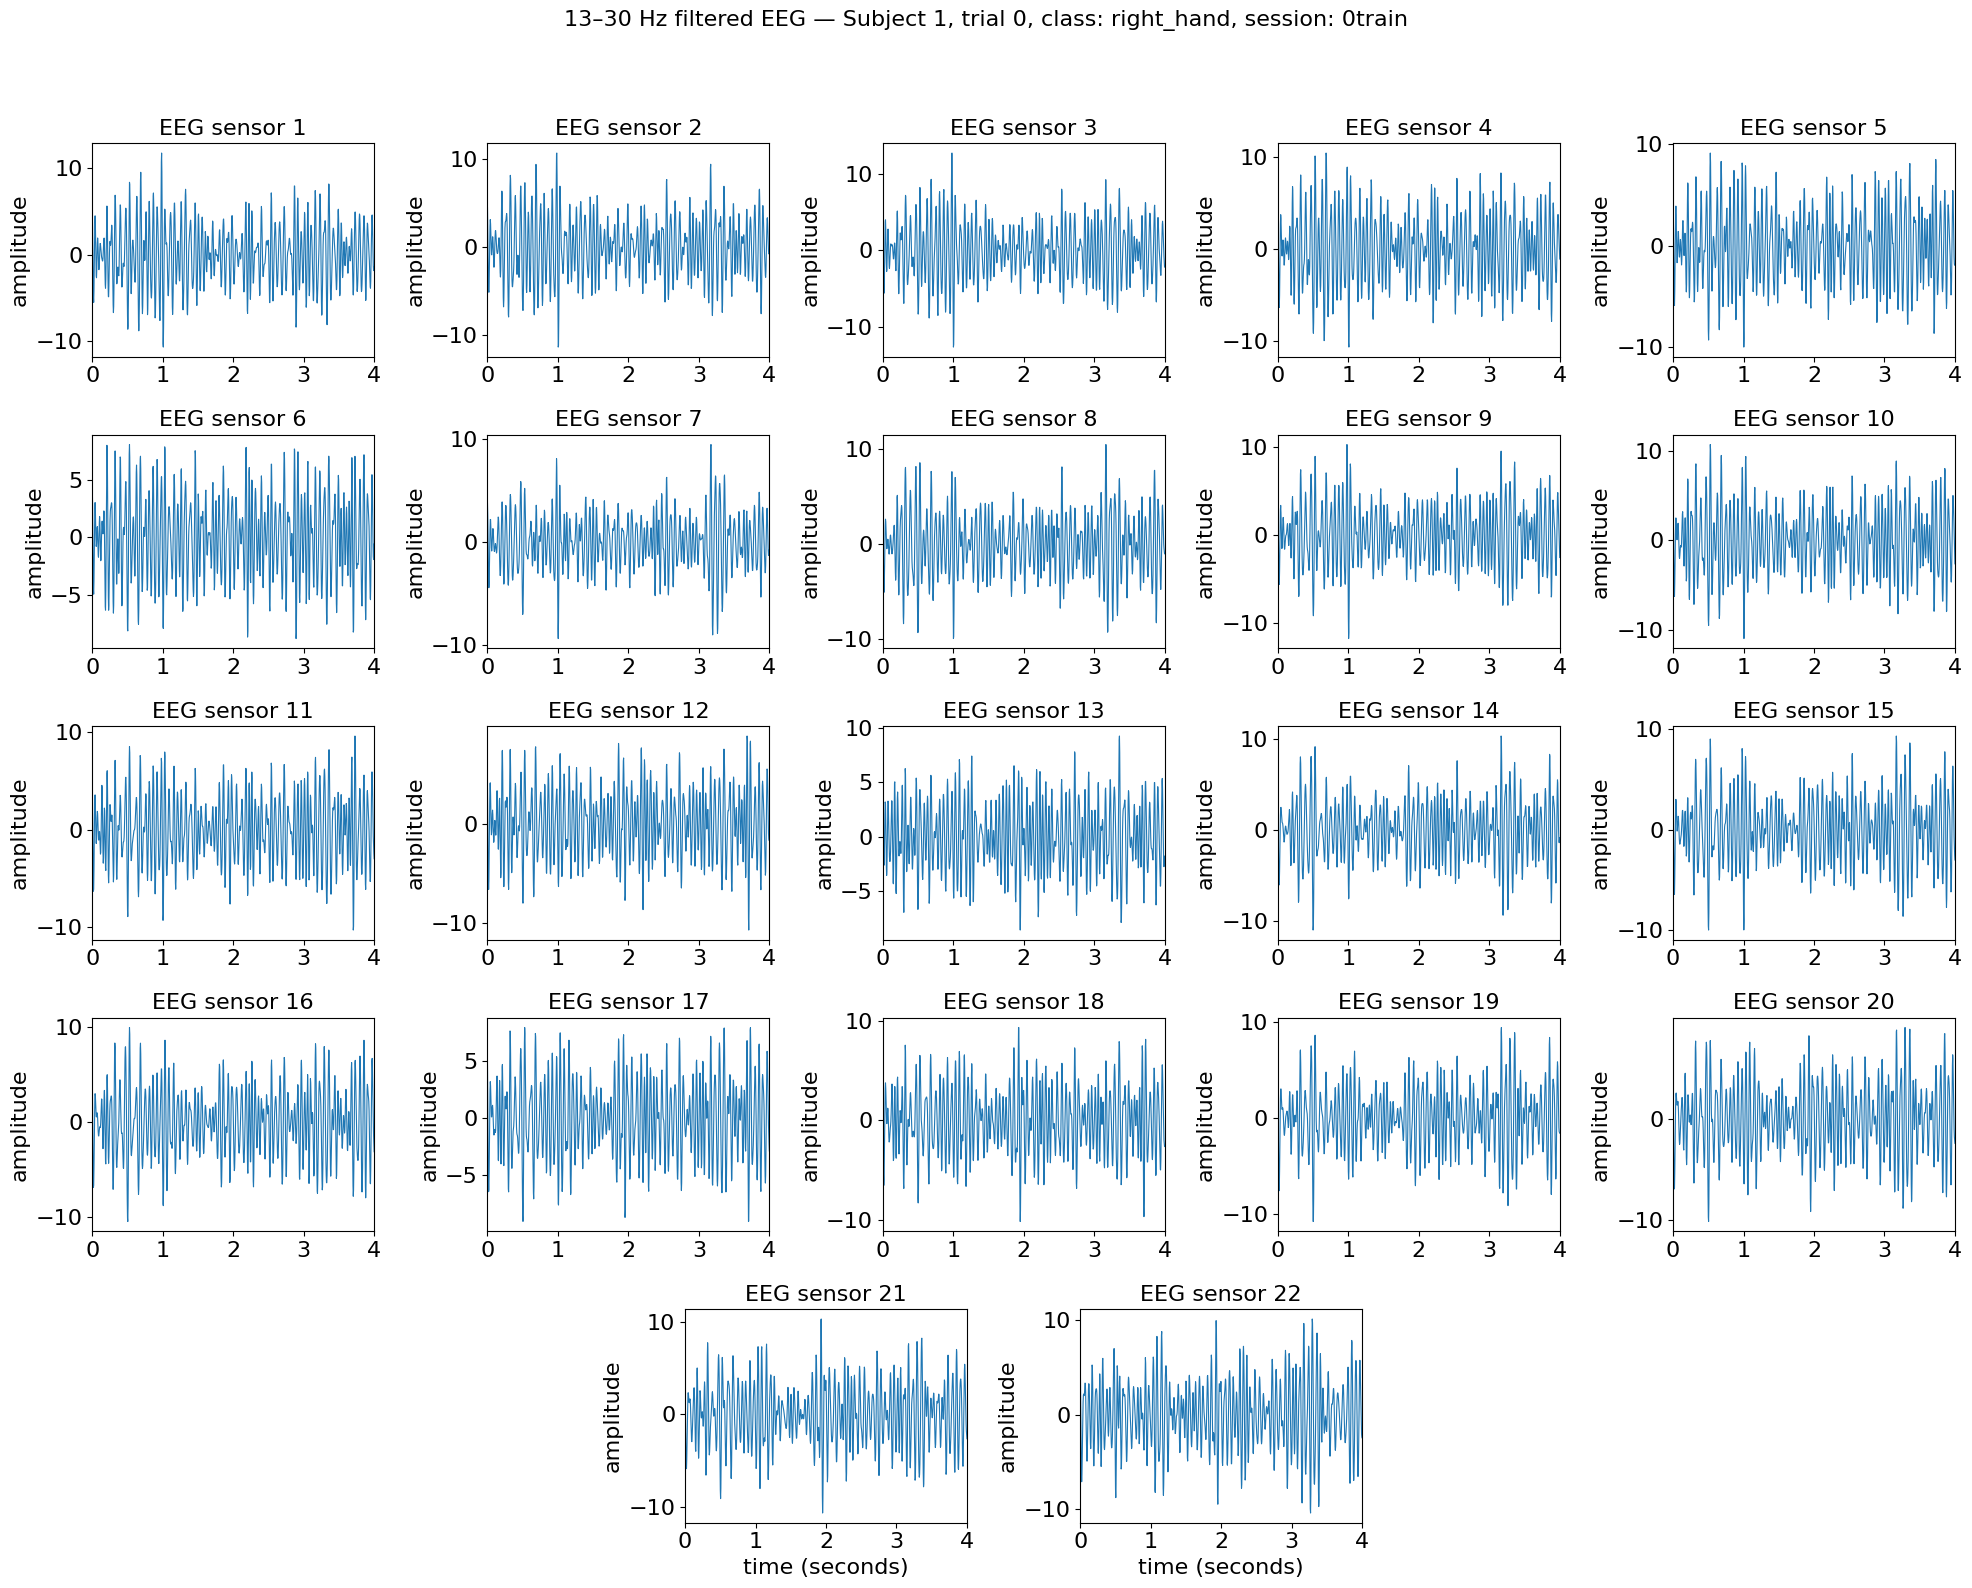

Saved figure: filtered_EEG_subject_1_trial_0.png


In [27]:
trial_index = 0

# Shape: (22 sensors, 1001 time samples)
trial = signals[trial_index] # selects a filtered EEG trial

sampling_rate = 250  # Hz
time = np.arange(trial.shape[1]) / sampling_rate
session = trial_info["session"].iloc[trial_index]

fig = plt.figure(figsize=(20, 16))
grid = fig.add_gridspec(5, 10)

axes = []

# First four rows: five plots per row.
for row in range(4):
    for col in range(5):
        axes.append(
            fig.add_subplot(
                grid[row, 2 * col : 2 * col + 2]
            )
        )

# Last row: two adjacent plots centered horizontally.
axes.append(fig.add_subplot(grid[4, 3:5]))
axes.append(fig.add_subplot(grid[4, 5:7]))

for sensor, ax in enumerate(axes):
    ax.plot(time, trial[sensor], linewidth=0.8)
    ax.set_title(f"EEG sensor {sensor + 1}")
    ax.set_ylabel("amplitude")
    ax.set_xlim(time[0], time[-1])

# Only the centered last-row panels receive x-axis labels.
for ax in axes[-2:]:
    ax.set_xlabel("time (seconds)")

fig.suptitle(
    f"13–30 Hz filtered EEG — Subject {SUBJECT}, "
    f"trial {trial_index}, class: {labels[trial_index]}, "
    f"session: {session}",
    y=0.995,
)

plt.tight_layout(rect=[0, 0, 1, 0.97])

output_name = (
    f"filtered_EEG_subject_{SUBJECT}_"
    f"trial_{trial_index}.png"
)

fig.savefig(
    output_name,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print(f"Saved figure: {output_name}")